In [4]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


In [7]:
pip install --upgrade nba_api


Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install nba_api pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


### On/Off Court Impact

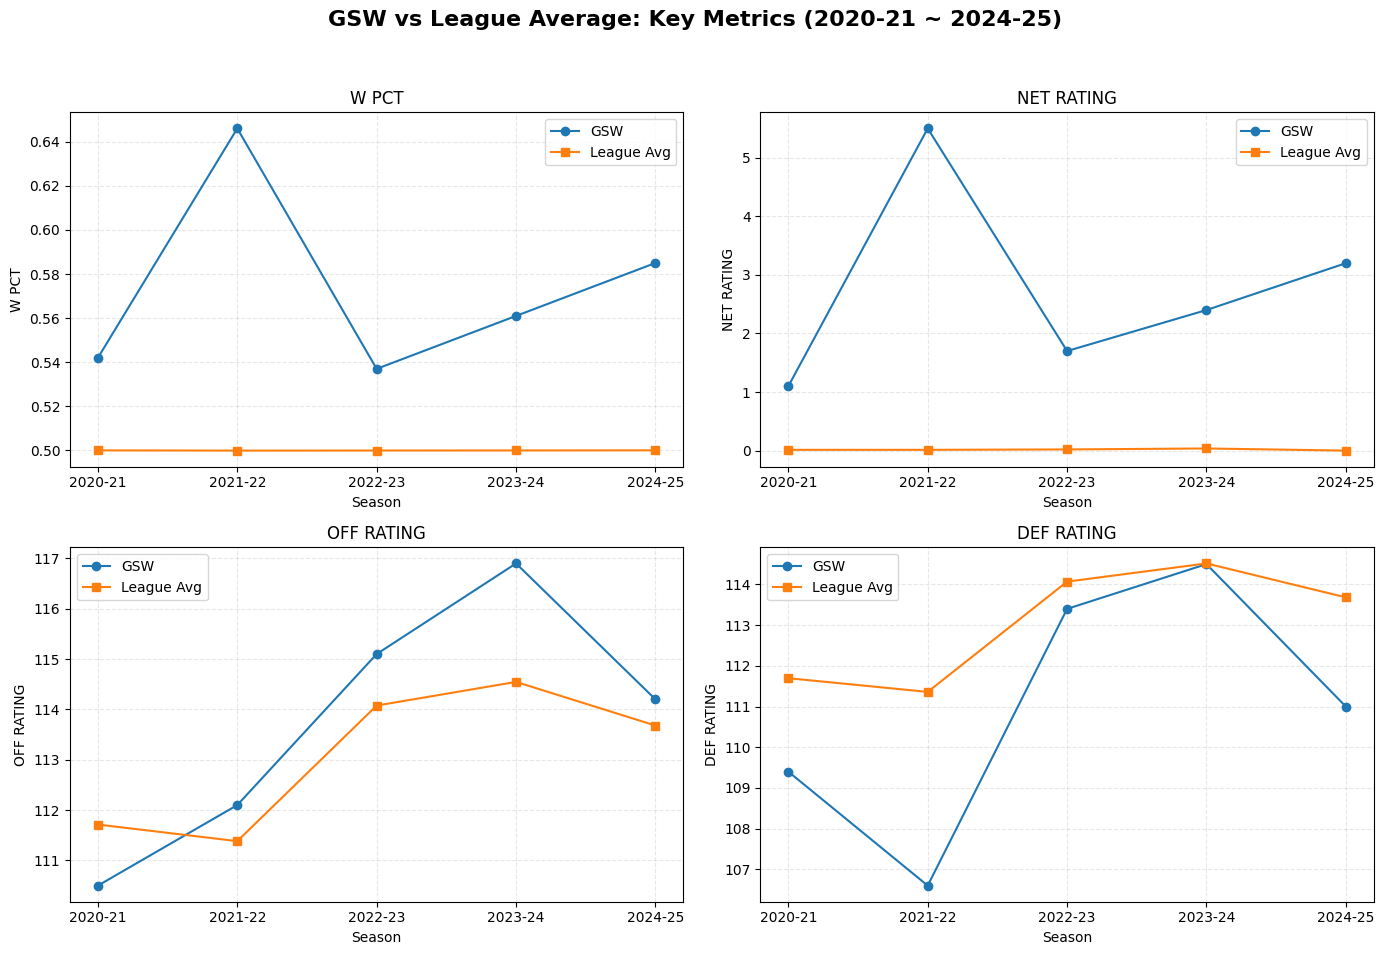

In [10]:

# ───────────────────────────────────────────────────────────────────────────
# 5. GSW 주요 지표 비교: 승률, Net Rating, ORTG, DRTG vs 리그 평균 (2020-21~2024-25)
# ───────────────────────────────────────────────────────────────────────────
seasons = [f"{y}-{str(y+1)[2:]}" for y in range(2020, 2025)]
team_id = 1610612744  # GSW 팀 ID
metrics = ['W_PCT', 'NET_RATING', 'OFF_RATING', 'DEF_RATING']

# 1) 시즌별 전체 리그 팀 통계 수집
records = []
for season in seasons:
    call = leaguedashteamstats.LeagueDashTeamStats(
        league_id_nullable='00',
        season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense='Advanced',
        per_mode_detailed='PerGame'
    )
    df = call.get_data_frames()[0]
    df['Season'] = season
    records.append(df)
league_df = pd.concat(records, ignore_index=True)

# 2) 리그 평균 계산
league_avg = (
    league_df.groupby('Season')[metrics]
    .mean()
    .rename(columns={m: m + '_LeagueAvg' for m in metrics})
    .reset_index()
)

# 3) GSW 데이터 추출
gsw_df = league_df[league_df['TEAM_ID'] == team_id][['Season', 'TEAM_NAME'] + metrics]

# 4) GSW vs 리그 평균 병합
after_merge = pd.merge(gsw_df, league_avg, on='Season')

# 5) 시각화: 시즌별 GSW vs 리그 평균 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    ax.plot(after_merge['Season'], after_merge[metric], marker='o', label='GSW')
    ax.plot(after_merge['Season'], after_merge[f'{metric}_LeagueAvg'], marker='s', label='League Avg')
    ax.set_title(metric.replace('_', ' '), fontsize=12)
    ax.set_xlabel('Season')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

fig.suptitle('GSW vs League Average: Key Metrics (2020-21 ~ 2024-25)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [31]:

# 6. 정제된 데이터 저장
df.to_csv('C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_net_ortg_drtg_rate.csv', index=False)
print("Cleaned data saved to CSV.")

Cleaned data saved to CSV.


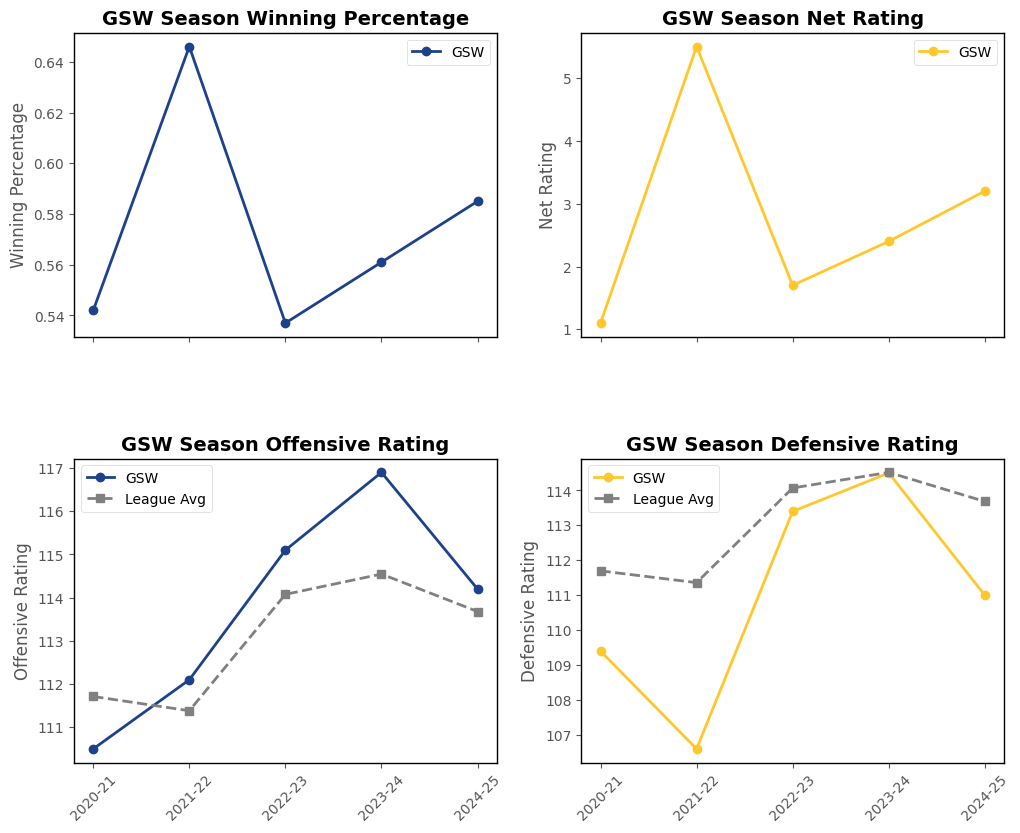

In [30]:
# Canvas: GSW 주요 지표 시각화 (테두리 추가, 깔끔한 레이블 정렬)
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leaguedashteamstats

# GSW 팀 컬러
gsw_blue = '#1D428A'
gsw_yellow = '#FFC72C'

# 파라미터 설정
seasons = [f"{y}-{str(y+1)[2:]}" for y in range(2020, 2025)]
team_id = 1610612744
metrics = ['W_PCT', 'NET_RATING', 'OFF_RATING', 'DEF_RATING']

# 리그 전체 팀 지표 수집
records = []
for season in seasons:
    call = leaguedashteamstats.LeagueDashTeamStats(
        league_id_nullable='00', season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense='Advanced',
        per_mode_detailed='PerGame'
    )
    df = call.get_data_frames()[0]
    df['Season'] = season
    records.append(df)
league_df = pd.concat(records, ignore_index=True)

# 리그 평균 및 GSW 데이터 준비
league_avg = (
    league_df.groupby('Season')[metrics]
    .mean()
    .rename(columns={m: m + '_LeagueAvg' for m in metrics})
    .reset_index()
)
gsw_df = league_df[league_df['TEAM_ID'] == team_id][['Season'] + metrics]
compare_df = pd.merge(gsw_df, league_avg, on='Season')

# 스타일 설정: 흰색 배경
plt.rcParams.update({'axes.facecolor':'white','figure.facecolor':'white'})

# 2x2 서브플롯
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

titles = ['Winning Percentage','Net Rating','Offensive Rating','Defensive Rating']
for ax, metric, title in zip(axes, metrics, titles):
    x = compare_df['Season']
    y = compare_df[metric]
    # 축 테두리 표시
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
    # GSW 선
    color = gsw_blue if metric in ['W_PCT','OFF_RATING'] else gsw_yellow
    ax.plot(x, y, marker='o', color=color, linewidth=2, label='GSW')
    # 리그 평균 선 (OFF/DEF)
    if metric in ['OFF_RATING','DEF_RATING']:
        y_avg = compare_df[f'{metric}_LeagueAvg']
        ax.plot(x, y_avg, marker='s', linestyle='--', color='gray', linewidth=2, label='League Avg')
    # (레이블 제거)
    # 제목/레이블
    ax.set_title(f"GSW Season {title}", fontsize=14, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_axisbelow(True)
    ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

# 레이아웃 조정
plt.subplots_adjust(bottom=0.15, hspace=0.4)
plt.show()
